  Step
  1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

 Step
 2. Load Dataset


In [ ]:
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Step
3. Data clean


In [ ]:
print('DataFrame Info:')
df.info()

print('\nMissing Values:')
display(df.isnull().sum())

print('\nDuplicate Rows:')
duplicate_rows = df.duplicated().sum()
print(f'{duplicate_rows} duplicate rows found.')

if duplicate_rows > 0:
    df_cleaned = df.drop_duplicates().copy()
    print('Duplicate rows removed.')
    print(f'New DataFrame shape: {df_cleaned.shape}')
else:
    df_cleaned = df.copy()
    print('No duplicate rows to remove.')

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Missing Values:


,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0



Duplicate Rows:
763 duplicate rows found.
Duplicate rows removed.
New DataFrame shape: (3577, 8)


 4.selling prices

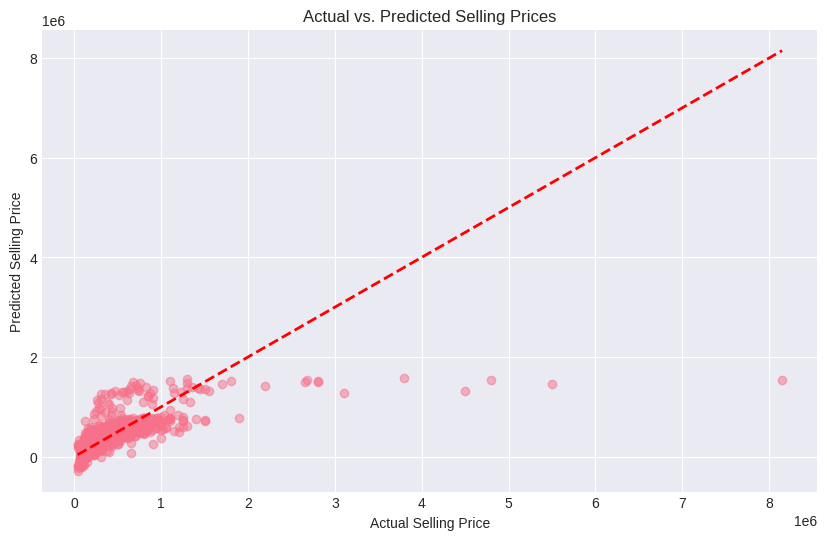

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs. Predicted Selling Prices')
plt.grid(True)
plt.show()

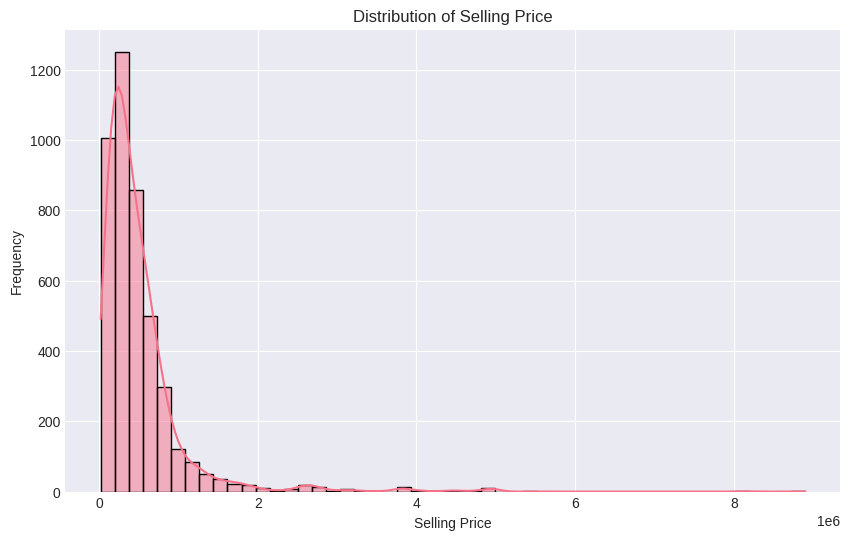

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], kde=True, bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

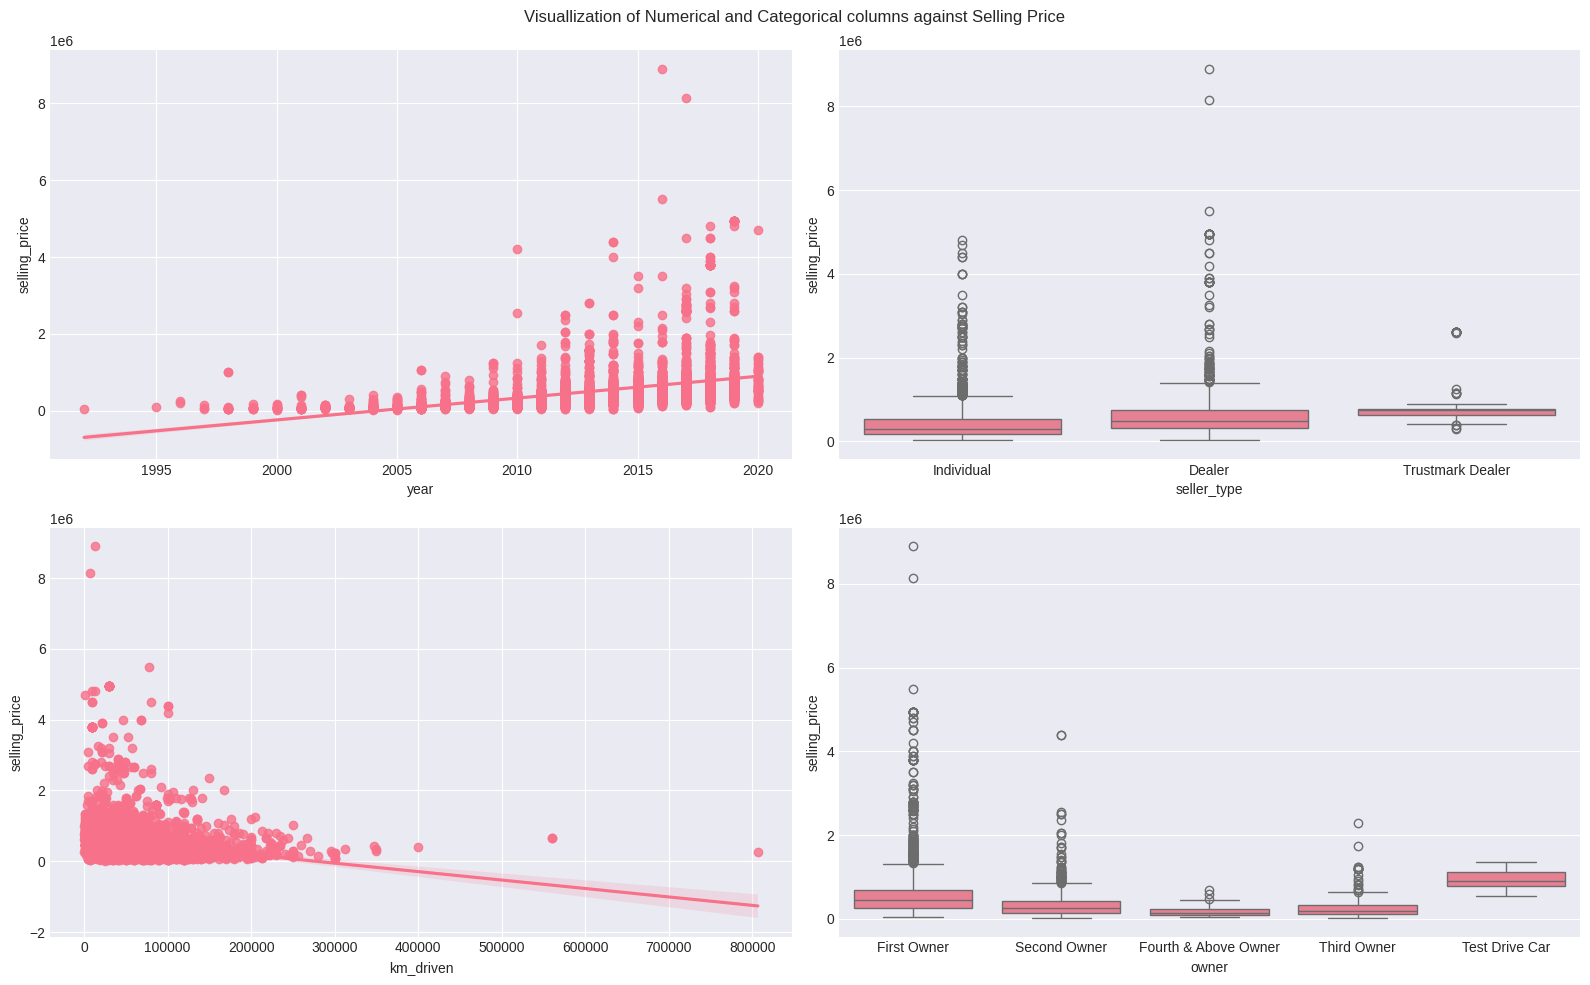

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (16,10))
fig.suptitle('Visuallization of Numerical and Categorical columns against Selling Price')

sns.regplot(x = 'year', y = 'selling_price', data = df, ax = axes[0,0])
sns.boxplot(x = 'seller_type', y = 'selling_price', data = df, ax = axes[0,1])
sns.regplot(x = 'km_driven', y = 'selling_price', data = df, ax = axes[1,0])
sns.boxplot(x = 'owner', y = 'selling_price', data = df, ax = axes[1,1])

plt.tight_layout()
plt.show()

## 5. Linear Regression — Baseline Model

### 5.1 Feature Engineering (One-Hot Encoding)

In [ ]:
df_encoded = pd.get_dummies(df_cleaned, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)
display(df_encoded.head())

,name,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti 800 AC,2007,60000,70000,False,False,False,True,True,False,True,False,False,False,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,True,True,False,True,False,False,False,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,True,False,False,False,True,False,True,False,False,False,False
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,True,True,False,True,False,False,False,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,True,False,False,False,True,False,True,False,True,False,False


### 5.2 Data Splitting

### 5.3 Linear Regression Model Training and Evaluation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error: 195633685392.37
R-squared (R2) Score: 0.39


In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

# Drop the 'name' column as it's not suitable for direct use in linear regression
X = X.drop('name', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2861, 13)
X_test shape: (716, 13)
y_train shape: (2861,)
y_test shape: (716,)


In [ ]:
print('--- Value Counts for Categorical Features ---')
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in categorical_cols:
    print(f'\nValue Counts for {col}:')
    print(df_cleaned[col].value_counts())
    print('-' * 30)

--- Value Counts for Categorical Features ---

Value Counts for fuel:
fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64
------------------------------

Value Counts for seller_type:
seller_type
Individual          2832
Dealer               712
Trustmark Dealer      33
Name: count, dtype: int64
------------------------------

Value Counts for transmission:
transmission
Manual       3265
Automatic     312
Name: count, dtype: int64
------------------------------

Value Counts for owner:
owner
First Owner             2218
Second Owner             978
Third Owner              289
Fourth & Above Owner      75
Test Drive Car            17
Name: count, dtype: int64
------------------------------


 Numerical Features Analysis

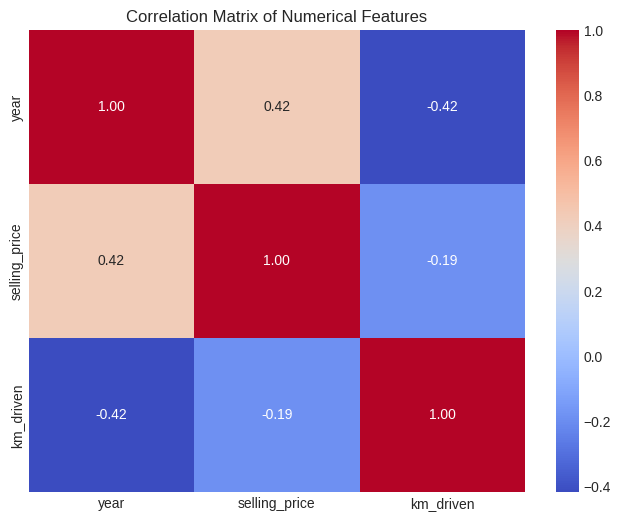

In [ ]:
numerical_df = df_cleaned[['year', 'selling_price', 'km_driven']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()